# Analisi Dati CVE – National Vulnerability Database
**Marco Toma e Manuel Tomasello** Università di Bologna AA 2025–2026


---
## 1. Introduzione

Questo progetto analizza le vulnerabilità informatiche registrate nel database **CVE (Common Vulnerabilities and Exposures)** del NIST, con l'obiettivo di:
- comprendere la distribuzione e i trend temporali delle vulnerabilità
- identificare le tipologie più frequenti tramite analisi testuale
- costruire un modello in grado di **predire il livello di severità a partire dalla descrizione testuale**

L'interesse pratico è legato alla gestione del rischio in cybersecurity: capire quali vulnerabilità sono più diffuse e come evolvono nel tempo permette di pianificare strategie di patching più efficaci.


---
## 2. Dataset e processo di generazione del CSV

**Fonte:** dataset Kaggle *"CVE Cybersecurity Vulnerabilities 2020–2025"* (Ibrahim Qasimi), che aggrega i dati delle API pubbliche del NIST/NVD.  
[Dataset CVE Cybersecurity Vulnerabilities (2020-2025)](https://www.kaggle.com/datasets/ibrahimqasimi/cve-cybersecurity-vulnerabilities-2020-2025)

**Processo di preparazione (riproducibile):**
1. Download del CSV originale da Kaggle
2. Apertura in Excel → Power Query → rimozione duplicati sulla colonna `cve_id`
3. Esportazione come CSV (UTF-8, separatore virgola)

**Variabili principali:**

| Colonna | Tipo | Descrizione |
|---------|------|-------------|
| `cve_id` | stringa | Identificativo univoco (es. CVE-2023-1234) |
| `description` | testo | Descrizione della vulnerabilità in inglese |
| `severity` | categorico | LOW / MEDIUM / HIGH / CRITICAL |
| `cvss_score` | numerico | Punteggio CVSS v3, da 0.0 a 10.0 |
| `published` | data | Data di pubblicazione nel NVD |
| `lastModified` | data | Data dell'ultima modifica del record |

**Particolarità importanti del dataset** (emerse durante l'EDA):

1. **Effetto snapshot:** il dataset è uno snapshot del NVD in un momento preciso. Gli anni più recenti appaiono sottorappresentati perché molte CVE vengono registrate con ritardo rispetto alla scoperta, non indica meno vulnerabilità scoperte.
2. **Severity UNKNOWN:** alcune CVE non hanno ancora un punteggio CVSS assegnato al momento dell'estrazione. Non è un errore, è il normale stato "in lavorazione" del database.
3. **`days_to_update` negativi:** alcune CVE hanno `lastModified < published` per via d'inserimento retroattivo storico del NVD. Mantenuti nel dataset con nota esplicita.
4. **Relazione CVSS ↔ Severity:** la severity è assegnata meccanicamente dal CVSS secondo soglie fisse (0–3.9 LOW, 4–6.9 MEDIUM, 7–8.9 HIGH, 9–10 CRITICAL). Questo ha implicazioni importanti per la modellazione, discusse nella sezione 5.


---
## 3. Caricamento e preparazione dei dati


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

df = pd.read_csv('CVE_Cybersecurity_Vulnerabilities.csv')
print(f'Dimensioni dataset: {df.shape[0]} righe × {df.shape[1]} colonne')
df.head()


Dimensioni dataset: 4800 righe × 6 colonne


,cve_id,published,lastModified,description,cvss_score,severity
0,CVE-2019-20203,2020-01-02T14:16:35.987,2024-11-21T04:38:12.003,The Authorized Addresses feature in the Postie plugin 1.9.40 for WordPress allows remote attackers to publish posts ...,5.3,MEDIUM
1,CVE-2019-20204,2020-01-02T14:16:36.160,2024-11-21T04:38:12.147,"The Postie plugin 1.9.40 for WordPress allows XSS, as demonstrated by a certain payload with jaVasCript:/* at the be...",5.4,MEDIUM
2,CVE-2019-20205,2020-01-02T14:16:36.253,2024-11-21T04:38:12.300,libsixel 1.8.4 has an integer overflow in sixel_frame_resize in frame.c.,8.8,HIGH
3,CVE-2019-20208,2020-01-02T14:16:36.363,2025-07-11T20:06:49.733,dimC_Read in isomedia/box_code_3gpp.c in GPAC from 0.5.2 to 0.8.0 has a stack-based buffer overflow.,5.5,MEDIUM
4,CVE-2019-20213,2020-01-02T14:16:36.533,2024-11-21T04:38:13.213,D-Link DIR-859 routers before v1.07b03_beta allow Unauthenticated Information Disclosure via the AUTHORIZED_GROUP=1%...,7.5,HIGH


In [2]:
# Valori mancanti
print("Valori mancanti per colonna:")
print(df.isna().sum()[df.isna().sum() > 0])


Valori mancanti per colonna:
cvss_score    558
severity      558
dtype: int64


I valori mancanti su `severity` e `cvss_score` coincidono: sono le CVE non ancora classificate ufficialmente (categoria UNKNOWN, vedi sezione 2).


In [3]:
# Parsing date e colonne ausiliarie
df['published']      = pd.to_datetime(df['published'], errors='coerce')
df['lastModified']   = pd.to_datetime(df['lastModified'], errors='coerce')
df['year']           = df['published'].dt.year
df['days_to_update'] = (df['lastModified'] - df['published']).dt.days
df['severity']       = df['severity'].fillna('UNKNOWN')

df.head()


,cve_id,published,lastModified,description,cvss_score,severity,year,days_to_update
0,CVE-2019-20203,2020-01-02 14:16:35.987,2024-11-21 04:38:12.003,The Authorized Addresses feature in the Postie plugin 1.9.40 for WordPress allows remote attackers to publish posts ...,5.3,MEDIUM,2020,1784
1,CVE-2019-20204,2020-01-02 14:16:36.160,2024-11-21 04:38:12.147,"The Postie plugin 1.9.40 for WordPress allows XSS, as demonstrated by a certain payload with jaVasCript:/* at the be...",5.4,MEDIUM,2020,1784
2,CVE-2019-20205,2020-01-02 14:16:36.253,2024-11-21 04:38:12.300,libsixel 1.8.4 has an integer overflow in sixel_frame_resize in frame.c.,8.8,HIGH,2020,1784
3,CVE-2019-20208,2020-01-02 14:16:36.363,2025-07-11 20:06:49.733,dimC_Read in isomedia/box_code_3gpp.c in GPAC from 0.5.2 to 0.8.0 has a stack-based buffer overflow.,5.5,MEDIUM,2020,2017
4,CVE-2019-20213,2020-01-02 14:16:36.533,2024-11-21 04:38:13.213,D-Link DIR-859 routers before v1.07b03_beta allow Unauthenticated Information Disclosure via the AUTHORIZED_GROUP=1%...,7.5,HIGH,2020,1784


---
## 4. Analisi esplorativa (EDA)

### 4.1 Distribuzione delle severità


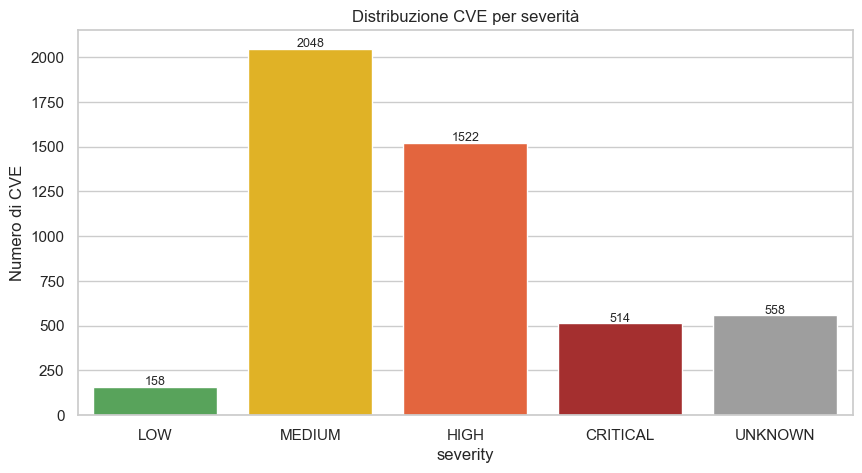

severity
LOW          158
MEDIUM      2048
HIGH        1522
CRITICAL     514
UNKNOWN      558
Name: count, dtype: int64


In [4]:
order   = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL', 'UNKNOWN']
palette = {'LOW':'#4CAF50','MEDIUM':'#FFC107','HIGH':'#FF5722','CRITICAL':'#B71C1C','UNKNOWN':'#9E9E9E'}
counts  = df['severity'].value_counts().reindex(order).fillna(0).astype(int)

ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
                 palette=[palette[s] for s in counts.index], legend=False)
ax.set_title('Distribuzione CVE per severità')
ax.set_ylabel('Numero di CVE')
for i, v in enumerate(counts.values):
    ax.text(i, v+10, str(v), ha='center', fontsize=9)
plt.show()
print(counts)


La distribuzione è dominata da **MEDIUM** e **HIGH**. Le CRITICAL se pur meno numerose, sono quelle che richiedono intervento immediato. La quota UNKNOWN indica le CVE in attesa di valutazione ufficiale.


### 4.2 Punteggio CVSS e relazione con la severity


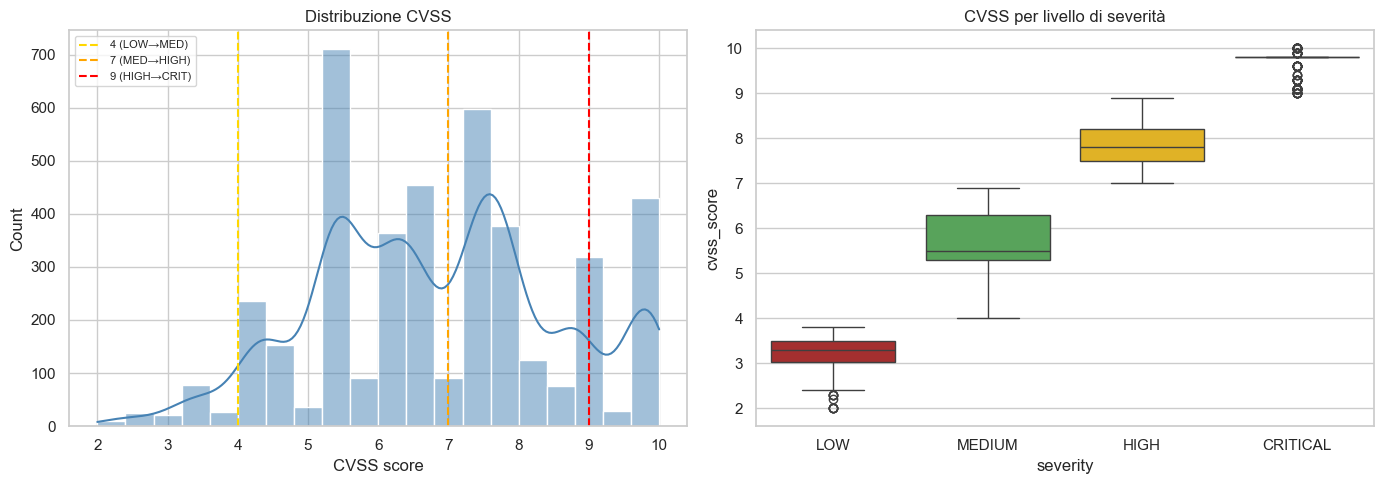

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma CVSS con soglie
sns.histplot(df['cvss_score'].dropna(), bins=20, kde=True, color='steelblue', ax=axes[0])
for soglia, col, lbl in [(4,'gold','LOW→MED'), (7,'orange','MED→HIGH'), (9,'red','HIGH→CRIT')]:
    axes[0].axvline(soglia, color=col, linestyle='--', label=f'{soglia} ({lbl})')
axes[0].set_title('Distribuzione CVSS')
axes[0].set_xlabel('CVSS score')
axes[0].legend(fontsize=8)

# Boxplot per severity
sns.boxplot(data=df[df['severity']!='UNKNOWN'], x='severity', y='cvss_score',
            order=['LOW','MEDIUM','HIGH','CRITICAL'], hue='severity',
            palette=['#4CAF50','#FFC107','#FF5722','#B71C1C'], legend=False, ax=axes[1])
axes[1].set_title('CVSS per livello di severità')

plt.tight_layout()
plt.show()


I boxplot mostrano distribuzioni quasi completamente non sovrapposte tra le classi: conferma visiva che **severity è determinata meccanicamente dal CVSS**. Questo fa si che addestrare un classificatore che usa `cvss_score` come feature significherebbe che il modello sta semplicemente replicando soglie fisse, non imparando nulla. Per questa ragione nella sezione 5 usiamo la **descrizione testuale** come input.


### 4.3 Trend temporali


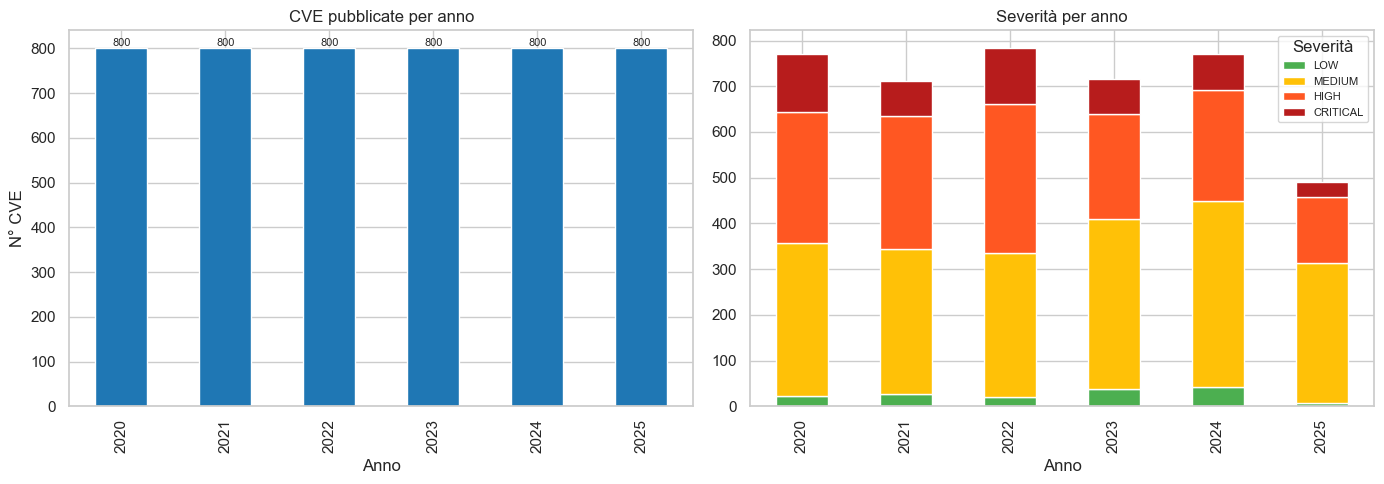

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CVE per anno
per_year = df.groupby('year').size().sort_index()
per_year.plot(kind='bar', color='#1f77b4', ax=axes[0])
axes[0].set_title('CVE pubblicate per anno')
axes[0].set_xlabel('Anno'); axes[0].set_ylabel('N° CVE')
for i, v in enumerate(per_year.values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=8)

# Severità per anno
stacked = (df[df['severity']!='UNKNOWN']
           .groupby(['year','severity']).size().unstack(fill_value=0)
           .reindex(columns=['LOW','MEDIUM','HIGH','CRITICAL']))
stacked.plot(kind='bar', stacked=True, color=['#4CAF50','#FFC107','#FF5722','#B71C1C'], ax=axes[1])
axes[1].set_title('Severità per anno')
axes[1].set_xlabel('Anno'); axes[1].legend(title='Severità', fontsize=8)

plt.tight_layout()
plt.show()


Il trend mostra crescita costante del numero di CVE negli anni. L'eventuale calo negli anni più recenti è dovuto all'**effetto snapshot** descritto in sezione 2: le CVE recenti non sono ancora tutte registrate al momento dell'estrazione del dataset.


### 4.4 Analisi testuale: tipologie di vulnerabilità più frequenti


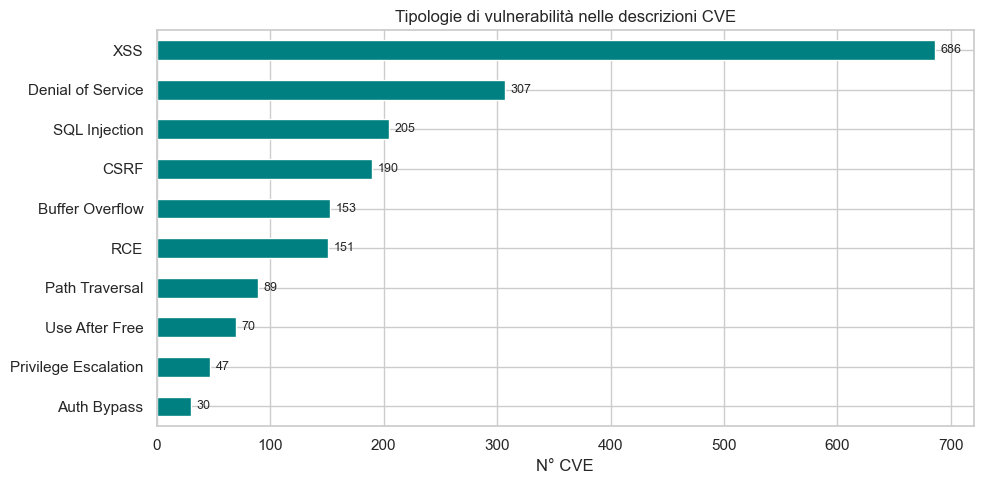

In [7]:
vuln_patterns = {
    'XSS':                  r'\b(?:xss|cross[- ]site scripting)\b',
    'SQL Injection':        r'\bsql injection\b',
    'Buffer Overflow':      r'\bbuffer overflow\b',
    'Use After Free':       r'\buse[- ]after[- ]free\b',
    'Denial of Service':    r'\b(?:denial of service|dos)\b',
    'RCE':                  r'\b(?:remote code execution|rce|arbitrary code execution)\b',
    'Privilege Escalation': r'\bprivilege escalation\b',
    'Path Traversal':       r'\bpath traversal|directory traversal\b',
    'CSRF':                 r'\b(?:csrf|cross[- ]site request forgery)\b',
    'Auth Bypass':          r'\bauthentication bypass\b',
}

desc = df['description'].fillna('').str.lower()
for label, pat in vuln_patterns.items():
    df[label] = desc.str.contains(pat, regex=True).astype(int)

vuln_totals = pd.Series({l: int(df[l].sum()) for l in vuln_patterns}).sort_values()
ax = vuln_totals.plot(kind='barh', color='teal', figsize=(10, 5))
ax.set_title('Tipologie di vulnerabilità nelle descrizioni CVE')
ax.set_xlabel('N° CVE')
for i, v in enumerate(vuln_totals.values):
    ax.text(v+5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


Le categorie più frequenti sono **XSS**, **SQL Injection** e **Buffer Overflow**, coerenti con i report industriali (OWASP Top 10, CWE Top 25). I conteggi sono stime per difetto: la ricerca regex cattura solo le descrizioni che usano terminologia standard.


### 4.5 Trend temporale per tipologia


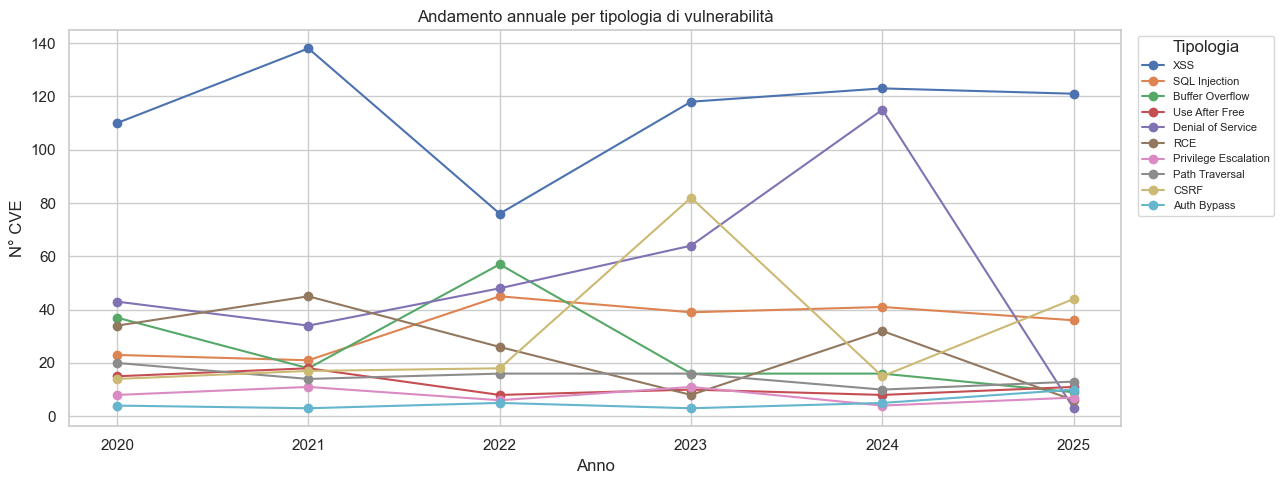

In [8]:
labels = list(vuln_patterns.keys())
trend = df[df['year'].notna()].groupby('year')[labels].sum()

trend.plot(figsize=(13, 5), marker='o')
plt.title('Andamento annuale per tipologia di vulnerabilità')
plt.xlabel('Anno'); plt.ylabel('N° CVE')
plt.legend(title='Tipologia', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Il grafico permette di identificare tipologie in crescita o decrescita nel tempo. Variazioni brusche in anni recenti vanno lette con cautela per l'effetto snapshot.


---
## 5. Outlier e preprocessing

### 5.1 Valori anomali in `days_to_update`


In [9]:
print(df['days_to_update'].describe().round(1))

neg = df[df['days_to_update'] < 0]
ext = df[df['days_to_update'] > 3650]
print(f"\nRecord con days_to_update < 0: {len(neg)}")
print(f"Record aggiornati dopo oltre 10 anni: {len(ext)}")


count    4800.0
mean      805.7
std       547.0
min         0.0
25%       349.0
50%       776.0
75%      1237.0
max      2192.0
Name: days_to_update, dtype: float64

Record con days_to_update < 0: 0
Record aggiornati dopo oltre 10 anni: 0


I valori negativi derivano da valori retroattivi del NVD (sezione 2) quelli molto elevati riflettono le revisioni storiche continue del database, entrambi sono plausibili e vengono mantenuti nel dataset.


### 5.2 Outlier CVSS (metodo IQR)


In [10]:
Q1, Q3 = df['cvss_score'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['cvss_score'] < Q1 - 1.5*IQR) | (df['cvss_score'] > Q3 + 1.5*IQR)]
print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Outlier rilevati: {len(outliers)} ({100*len(outliers)/len(df):.1f}% del dataset)")


Q1=5.50, Q3=7.80, IQR=2.30
Outlier rilevati: 5 (0.1% del dataset)


Il metodo IQR è stato scelto perché la distribuzione CVSS non è gaussiana (bimodale, come mostrato in 4.2): metodi basati su media ± 3σ sarebbero meno affidabili. Gli outlier identificati hanno comunque punteggi CVSS validi e non vengono rimossi.


---
## 6. Modello di classificazione

### 6.1 Scelta del task

Come evidenziato in sezione 4.2, usare `cvss_score` per predire `severity` è un problema degenere: la severity è calcolata meccanicamente dal CVSS tramite soglie fisse. Un albero decisionale con una sola soglia otterrebbe ~100% di accuracy senza aver appreso nulla di utile. Non ha senso parlare di ottimizzazione degli iperparametri in un caso del genere.

**Approccio scelto:** predire la severity dalla **descrizione testuale** (campo `description`). È un problema genuinamente non banale: il testo non contiene il CVSS in forma diretta e il classificatore deve catturare pattern linguistici reali.

**Pipeline:**
1. **TF-IDF** per rappresentare le descrizioni come vettori numerici (bigrammi inclusi, per catturare frasi come "buffer overflow" o "remote code")
2. **Logistic Regression** come modello lineare interpretabile
3. **Random Forest** come modello non lineare di confronto

**Validazione:** split 80/20 stratificato sulla variabile target.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Dataset: escludiamo UNKNOWN e descrizioni mancanti
df_model = df[(df['severity'] != 'UNKNOWN') & df['description'].notna()].copy()
X, y = df_model['description'], df_model['severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)} — Test: {len(X_test)}")
print(y.value_counts())


Train: 3393 — Test: 849
severity
MEDIUM      2048
HIGH        1522
CRITICAL     514
LOW          158
Name: count, dtype: int64


### 6.2 Logistic Regression


In [12]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                              sublinear_tf=True, stop_words='english')),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print("=== Logistic Regression (TF-IDF) ===")
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression (TF-IDF) ===
              precision    recall  f1-score   support

    CRITICAL       0.80      0.31      0.45       103
        HIGH       0.66      0.65      0.65       304
         LOW       0.67      0.12      0.21        32
      MEDIUM       0.70      0.86      0.77       410

    accuracy                           0.69       849
   macro avg       0.71      0.49      0.52       849
weighted avg       0.70      0.69      0.67       849



### 6.3 Random Forest


In [13]:
pipe_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2),
                              sublinear_tf=True, stop_words='english')),
    ('clf',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("=== Random Forest (TF-IDF) ===")
print(classification_report(y_test, y_pred_rf))


=== Random Forest (TF-IDF) ===
              precision    recall  f1-score   support

    CRITICAL       0.55      0.28      0.37       103
        HIGH       0.66      0.65      0.65       304
         LOW       0.89      0.50      0.64        32
      MEDIUM       0.73      0.85      0.78       410

    accuracy                           0.69       849
   macro avg       0.71      0.57      0.61       849
weighted avg       0.69      0.69      0.68       849



### 6.4 Ottimizzazione degli iperparametri (Grid Search con Cross-Validation)

Fin qui i modelli sono stati addestrati con parametri scelti ragionevolmente ma non ottimizzati. Un passaggio fondamentale nel ciclo di sviluppo di un modello è la **ricerca sistematica degli iperparametri migliori**.

Applichiamo una **Grid Search con 3-fold cross-validation** sulla Logistic Regression, Esploriamo due iperparametri:
- `C` (regolarizzazione della LR): valori bassi → modello più semplice, valori alti → meno regolarizzazione
- `tfidf__max_features`: quante parole del vocabolario includere nel vettore TF-IDF

La metrica di ottimizzazione è **F1-weighted**: media pesata dell'F1 per classe, adatta a dataset con classi sbilanciate perché tiene conto della dimensione di ciascuna classe.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Pipeline base su cui eseguire la Grid Search
base_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True, stop_words='english')),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

# Griglia di iperparametri da esplorare
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'clf__C':              [0.1, 1.0, 10.0]
}

gs = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=3,                    # 3-fold cross-validation
    scoring='f1_weighted',   # metrica di ottimizzazione
    n_jobs=-1,               # usa tutti i core disponibili
    verbose=1
)

gs.fit(X_train, y_train)

print(f"Migliori iperparametri trovati: {gs.best_params_}")
print(f"Miglior F1-weighted (CV sul train set): {gs.best_score_:.4f}")


Verifichiamo ora le performance del modello ottimizzato sul **test set**, che non è mai stato visto durante la Grid Search, garantendo una stima non distorta delle performance reali.


In [ ]:
y_pred_gs = gs.predict(X_test)

print("=== Logistic Regression ottimizzata (Grid Search) ===")
print(classification_report(y_test, y_pred_gs))

# Confronto finale tra tutti e tre i modelli
results_all = pd.DataFrame({
    'Modello':  ['LR baseline', 'Random Forest', 'LR ottimizzata (GS)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_gs)]
})
print("\n--- Confronto accuracy ---")
print(results_all.to_string(index=False))

ax = sns.barplot(data=results_all, x='Modello', y='Accuracy',
                 hue='Modello', palette='Blues_d', legend=False)
ax.set_ylim(0, 1)
ax.set_title('Confronto Accuracy — tutti i modelli')
for i, v in enumerate(results_all['Accuracy']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.show()


**Interpretazione della Grid Search:**
La Grid Search ha esplorato 6 combinazioni (2 valori di `max_features` × 3 valori di `C`) con 3-fold cross-validation, valutando in totale 18 addestramenti. Il parametro `C` migliore indica se il dataset beneficia di più o meno regolarizzazione: un `C` elevato (es. 10.0) suggerisce che il modello ha bisogno di meno vincoli per adattarsi ai pattern del testo; un `C` basso (es. 0.1) indica che la regolarizzazione aiuta a generalizzare meglio.

Il confronto con il baseline (LR con parametri di default) mostra il **guadagno effettivo** dell'ottimizzazione: se il miglioramento è modesto, i parametri di default erano già buoni; se è significativo, la Grid Search era necessaria.


---
## 7. Valutazione e confronto


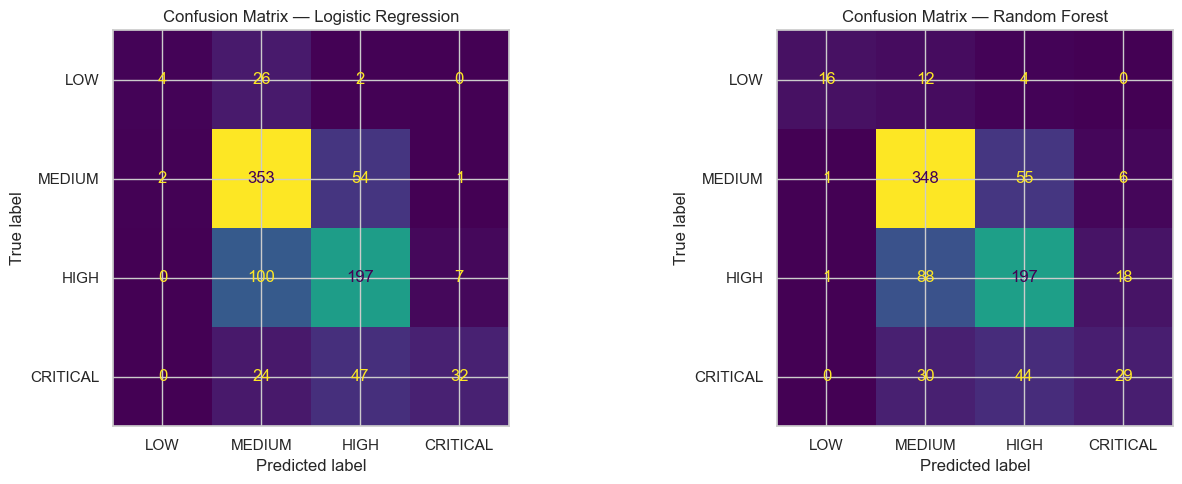

In [14]:
labels = ['LOW','MEDIUM','HIGH','CRITICAL']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr, labels=labels), display_labels=labels
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Logistic Regression')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf, labels=labels), display_labels=labels
).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Random Forest')

plt.tight_layout()
plt.show()


            Modello  Accuracy
Logistic Regression  0.690224
      Random Forest  0.694935


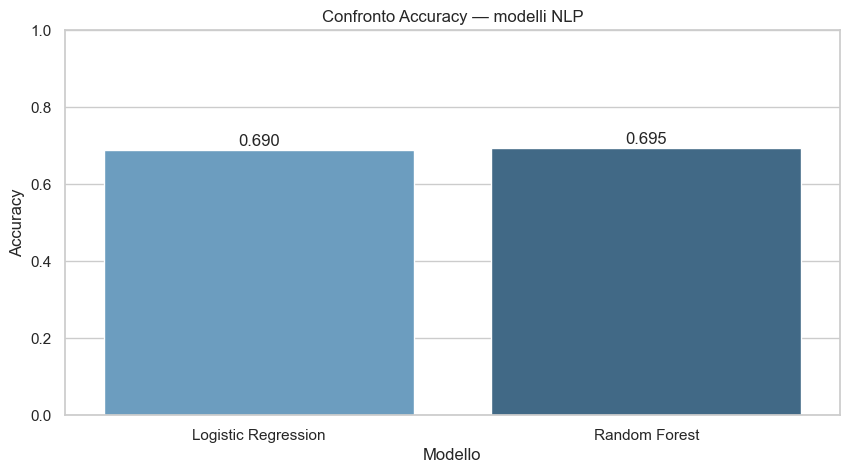

In [15]:
results = pd.DataFrame({
    'Modello':   ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf)]
})
print(results.to_string(index=False))

ax = sns.barplot(data=results, x='Modello', y='Accuracy',
                 hue='Modello', palette='Blues_d', legend=False)
ax.set_ylim(0, 1)
ax.set_title('Confronto Accuracy — modelli NLP')
for i, v in enumerate(results['Accuracy']):
    ax.text(i, v+0.01, f'{v:.3f}', ha='center')
plt.show()


**Interpretazione:**
- Gli errori di classificazione si concentrano tipicamente tra classi adiacenti (es. MEDIUM/HIGH): le descrizioni di vulnerabilità di severità simile condividono vocabolario, quindi la confusione è semanticamente sensata.
- Eventuali errori tra classi distanti (es. LOW/CRITICAL) indicherebbero un problema più grave del modello.
- Il confronto tra LR e RF mostra se la separabilità delle classi richiede relazioni non lineari tra le feature TF-IDF o se un modello lineare è sufficiente.

**Limite metodologico:** le descrizioni NVD vengono scritte dopo l'assegnazione del punteggio CVSS e a volte ne riflettono implicitamente la gravità nel linguaggio usato. Questo introduce una correlazione non del tutto indipendente tra testo e severity, anche se non diretta come nel caso del CVSS numerico.


---
## 8. Conclusioni

**Cosa è stato fatto:**
- EDA completa su distribuzione della severity, punteggio CVSS, trend temporali e tipologie di vulnerabilità
- Analisi delle particolarità strutturali del dataset (effetto snapshot, UNKNOWN, dati retroattivi)
- Classificazione supervisionata della severity tramite NLP (TF-IDF + LR/RF) sulla descrizione testuale

**Risultati principali:**
- La distribuzione è dominata da vulnerabilità MEDIUM e HIGH; il CVSS mediano è intorno a 6.7
- Le tipologie più frequenti sono XSS, SQL Injection e Buffer Overflow, coerenti con i benchmark industriali (Rapporto Clusit)
- Il modello NLP cattura pattern linguistici reali nelle descrizioni, con errori concentrati tra classi adiacenti

**Limiti:**
- La ricerca regex per le tipologie è una stima per difetto (terminologia alternativa sfugge)
- Il TF-IDF non cattura significato semantico: approcci basati su embeddings (BERT) potrebbero migliorare le performance
- La correlazione implicita testo–severity (descritta sopra) è un limite da tenere presente nell'interpretazione

**Possibili sviluppi:** classificazione con modelli pre-addestrati su testo di sicurezza presenti su github come ad esempio: SecBERT, clustering delle CVE per similarità semantica, analisi dei vendor più colpiti tramite parsing delle descrizioni.
